In [19]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_full.csv', dtype=None, delimiter=',', skip_header=1) 
X = iris[:, :4]
y = iris[:, 4]

maxi = np.max(X)
mini = np.min(X)

X = (X-mini)/(maxi-mini)

intercept =np.ones((X.shape[0], 1))
X = np.concatenate((intercept, X),axis =1)

inds = np.arange(X.shape[0]) #Tạo 1 array chứa các số từ 1-> 100
np.random.shuffle(inds) #Xáo các vị trí

X = X[inds]
y =y[inds]

print(X.shape)
print(y.shape)


(100, 5)
(100,)


In [20]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def loss_function(y_hat, y):
    return (-y*np.log(y_hat) - (1-y)*np.log(1-y_hat)).mean()

def predict(X, theta):    
    y_hat = sigmoid_function(np.dot(X, theta))
    return y_hat

def compute_gradient(X, y_hat, y):
    return np.dot(X.T, (y_hat - y)) / y.size

In [21]:
lr=0.01
num_iter=50000

theta = np.array([0.01, 0.05, 0.01, 0.5, -0.1])

losses = []
accs   = []

for i in range(num_iter):
    y_hat = predict(X,theta)

    loss = loss_function(y_hat,y)

    gradient = compute_gradient(X, y_hat, y)

    theta -= lr*gradient   


    if i % 1 ==0: #vẽ đồ thị cho dễ nhìn
        losses.append(loss)

        #accuracy for training
        preds = predict(X, theta).round()
        acc = (preds==y).mean()
        accs.append(acc)
    
    
    

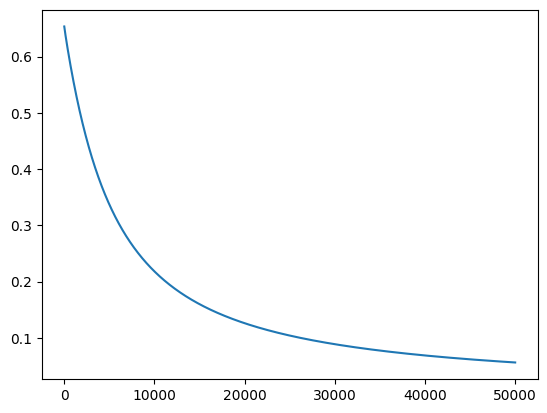

In [22]:
plt.plot(losses)
plt.show()

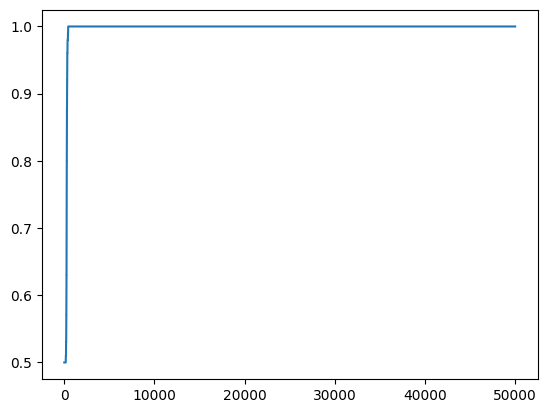

In [23]:
plt.plot(accs)
plt.show()

In [24]:
preds = predict(X, theta).round()
print(preds)
print(y)

[0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1.
 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1.
 0. 1. 0. 0.]
[0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1.
 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1.
 0. 1. 0. 0.]
